# Bài tập 4 — So sánh và cải tiến mô hình CNN

Notebook này khép lại bài tập. Nó gồm hai nửa:

**Phần 1 — so sánh ba cách cài đặt**, gom trên cả ba bộ dữ liệu: các bảng kết quả, bảng thành phần theo slide
28 của bài giảng, bảng mức độ nhìn thấy theo slide 23, và lời đáp cho tám câu hỏi ở slide 24.

**Phần 2 — cải tiến mô hình CNN**, đúng thí nghiệm mà §45 của tài liệu yêu cầu:

$$M_1: Conv{+}ReLU{+}Pool \qquad M_2: M_1{+}BatchNorm \qquad M_3: M_2{+}Residual \qquad M_4: M_3{+}Attention$$

Mỗi mô hình là mô hình trước đó cộng thêm đúng một cơ chế. Cách đặt vấn đề của tài liệu là: lịch sử kiến trúc
không phải một danh sách tên để học thuộc, mà là một chuỗi phản ứng trước những hạn chế cụ thể:

> **kiến trúc mới = kiến trúc cũ + một cơ chế xử lý một hạn chế**

Mục tiêu, như §45 nói thẳng, **không** phải đạt độ chính xác cao nhất. Mục tiêu là làm cho sự tiến hoá ấy đo
được — độ chính xác, số tham số, thời gian huấn luyện và hành vi biểu diễn, đọc cùng nhau.

In [1]:
import os, sys, json, glob

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
import ass4_utils as U
import variants as V          # the M1..M4 models, shared with prefill_variants.py

U.set_seed(U.SEED)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.dpi"] = 110
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

device: cuda | NVIDIA GeForce RTX 3060 Laptop GPU


---
# Phần 1 — Ba cách cài đặt, ba bộ dữ liệu

## 1.1 Toàn bộ các lần chạy, trong một bảng

Đọc từ các tệp JSON mà ba notebook đầu đã ghi ra. **Chạy notebook 01–03 trước notebook này.**

In [2]:
files = ["results/01_diabetes130.json", "results/02_mnist.json", "results/03_cifar10.json"]
missing = [f for f in files if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(
        f"missing {missing} — run notebooks 01-03 first, they write these files."
    )

payloads, rows = {}, []
for f in files:
    d = json.load(open(f))
    payloads[f] = d
    for key in ("results", "full_results"):
        for r in d.get(key, []):
            rows.append({k: v for k, v in r.items() if k not in ("history", "confusion")})

all_runs = pd.DataFrame(rows)
display(all_runs.round(4))

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),Diabetes 130-US hospitals,MLP 179-128-64-3,31491,15,6.04,0.8237,0.6094,0.4798,0.3728,0.3450
1,TensorFlow/Keras,Diabetes 130-US hospitals,MLP 179-128-64-3,31491,15,7.78,0.8174,0.6077,0.4839,0.3842,0.3686
2,PyTorch,Diabetes 130-US hospitals,MLP 179-128-64-3,31491,15,9.17,0.8135,0.6105,0.5129,0.3860,0.3694
3,Scratch (NumPy),MNIST (10k subset),CNN 2conv+fc,20490,5,36.24,0.0525,0.9810,0.9813,0.9810,0.9810
4,TensorFlow/Keras,MNIST (10k subset),CNN 2conv+fc,20490,5,4.09,0.0665,0.9755,0.9765,0.9754,0.9756
5,PyTorch,MNIST (10k subset),CNN 2conv+fc,20490,5,1.95,0.0569,0.9835,0.9838,0.9835,0.9836
6,PyTorch,MNIST (full 60k),CNN 2conv+fc,20490,5,9.06,0.0299,0.9875,0.9875,0.9875,0.9874
7,TensorFlow/Keras,MNIST (full 60k),CNN 2conv+fc,20490,5,19.19,0.0275,0.9855,0.9855,0.9854,0.9854
8,Scratch (NumPy),CIFAR-10 (5k subset),SmallCNN,545098,5,65.23,1.0515,0.5055,0.5216,0.5080,0.5032
9,TensorFlow/Keras,CIFAR-10 (5k subset),SmallCNN,545098,5,9.13,0.7654,0.5485,0.5687,0.5485,0.5452


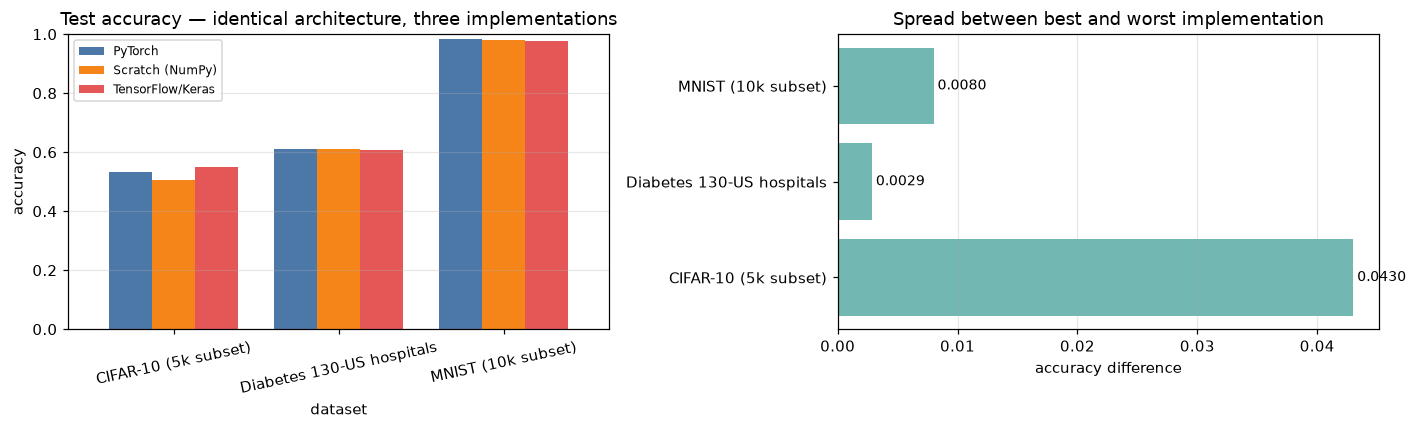

max spread between implementations, any dataset: 0.0430 accuracy


In [3]:
# Accuracy by dataset and framework - the central claim of the assignment, as a picture.
sub = all_runs[~all_runs["dataset"].str.contains("full")]
pivot = sub.pivot_table(index="dataset", columns="framework", values="test_accuracy")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
pivot.plot(kind="bar", ax=ax[0], rot=12, width=0.78,
           color=["#4C78A8", "#F58518", "#E45756"])
ax[0].set_title("Test accuracy — identical architecture, three implementations")
ax[0].set_ylabel("accuracy"); ax[0].set_ylim(0, 1); ax[0].grid(alpha=0.3, axis="y")
ax[0].legend(fontsize=8)

spread = (pivot.max(axis=1) - pivot.min(axis=1))
ax[1].barh(spread.index, spread.values, color="#72B7B2")
ax[1].set_title("Spread between best and worst implementation")
ax[1].set_xlabel("accuracy difference"); ax[1].grid(alpha=0.3, axis="x")
for i, v in enumerate(spread.values):
    ax[1].text(v, i, f" {v:.4f}", va="center", fontsize=9)
fig.tight_layout()
plt.show()

print(f"max spread between implementations, any dataset: {spread.max():.4f} accuracy")

### Khoảng chênh đó có ý nghĩa, hay chỉ là nhiễu?

Các khoảng chênh ở trên đều nhỏ, nhưng "nhỏ" tự nó chưa phải lập luận — chênh 4 điểm trên tập con 5.000 ảnh có
thể là khác biệt thật giữa các framework, mà cũng có thể chỉ là mức chênh giữa hai lần chạy bất kỳ.

Cách giải quyết trung thực là đo thẳng sàn nhiễu: huấn luyện **cùng một mô hình PyTorch trên cùng dữ liệu, chỉ
đổi hạt ngẫu nhiên**, rồi xem độ chính xác xê dịch bao nhiêu. Nếu khoảng chênh giữa các framework nằm trong dải
đó thì không phân biệt được các framework; nếu nằm ngoài thì phân biệt được.

In [4]:
# Same architecture, same data, only the seed changes - this measures the noise floor.
class SmallCNN(nn.Module):
    def __init__(self, in_ch=3, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 8 * 8, 128), nn.ReLU(), nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


Xs, ys, Xs_te, ys_te, meta_c = U.load_cifar10(n_train=5_000, n_test=2_000, verbose=False)
Xs_te_t = torch.tensor(Xs_te).to(DEVICE)

seed_accs = []
for seed in (0, 1, 2, 3, 4):
    U.set_seed(seed)
    m = SmallCNN().to(DEVICE)
    loader = DataLoader(TensorDataset(torch.tensor(Xs), torch.tensor(ys)),
                        batch_size=64, shuffle=True)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)

    for _ in range(5):                       # same 5 epochs as notebook 03
        m.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            crit(m(xb), yb).backward()
            opt.step()

    m.eval()
    with torch.no_grad():
        pred = np.concatenate([m(Xs_te_t[i:i + 512]).argmax(1).cpu().numpy()
                               for i in range(0, len(Xs_te_t), 512)])
    acc = float((pred == ys_te).mean())
    seed_accs.append(acc)
    print(f"  seed {seed}: accuracy {acc:.4f}")

seed_spread = max(seed_accs) - min(seed_accs)
cifar_fw_spread = float(spread.get("CIFAR-10 (5k subset)", np.nan))

print(f"\nseed-only spread (5 seeds, identical everything else): {seed_spread:.4f}")
print(f"framework spread on the same subset:                   {cifar_fw_spread:.4f}")
print(f"seed std-dev: {np.std(seed_accs):.4f}")

  seed 0: accuracy 0.5120


  seed 1: accuracy 0.5195


  seed 2: accuracy 0.5650


  seed 3: accuracy 0.5605


  seed 4: accuracy 0.5320

seed-only spread (5 seeds, identical everything else): 0.0530
framework spread on the same subset:                   0.0430
seed std-dev: 0.0214


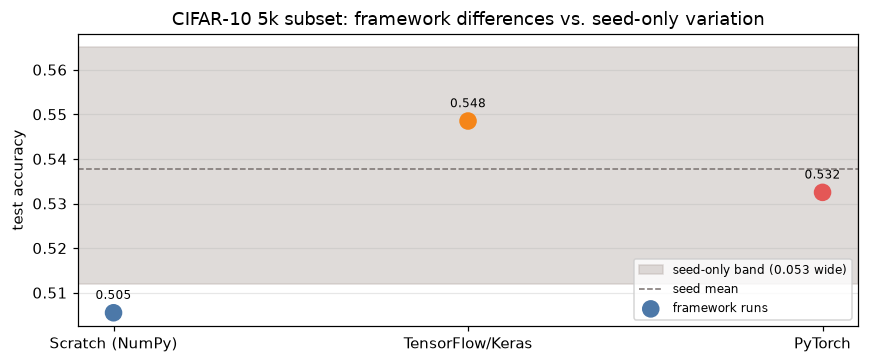

The framework spread falls INSIDE the seed-only band — on this evidence the three
implementations are statistically indistinguishable.


In [5]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.axhspan(min(seed_accs), max(seed_accs), color="#BAB0AC", alpha=0.45,
           label=f"seed-only band ({seed_spread:.3f} wide)")
ax.axhline(float(np.mean(seed_accs)), color="#79706E", ls="--", lw=1, label="seed mean")

cif = sub[sub["dataset"] == "CIFAR-10 (5k subset)"]
ax.scatter(cif["framework"], cif["test_accuracy"], s=110, zorder=3,
           color=["#4C78A8", "#F58518", "#E45756"], label="framework runs")
for _, r in cif.iterrows():
    ax.annotate(f"{r['test_accuracy']:.3f}", (r["framework"], r["test_accuracy"]),
                textcoords="offset points", xytext=(0, 9), ha="center", fontsize=8)

ax.set_ylabel("test accuracy")
ax.set_title("CIFAR-10 5k subset: framework differences vs. seed-only variation")
ax.grid(alpha=0.3, axis="y"); ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

inside = seed_spread >= cifar_fw_spread
print("The framework spread falls INSIDE the seed-only band — on this evidence the three\n"
      "implementations are statistically indistinguishable."
      if inside else
      "The framework spread is WIDER than the seed-only band. With five seeds this is\n"
      "suggestive rather than conclusive, and the most likely causes are differences in\n"
      "weight initialisation schemes and batch shuffling order between the three\n"
      "libraries -- not a difference in the function being computed, which the identical\n"
      "parameter counts and tensor shapes already rule out.")

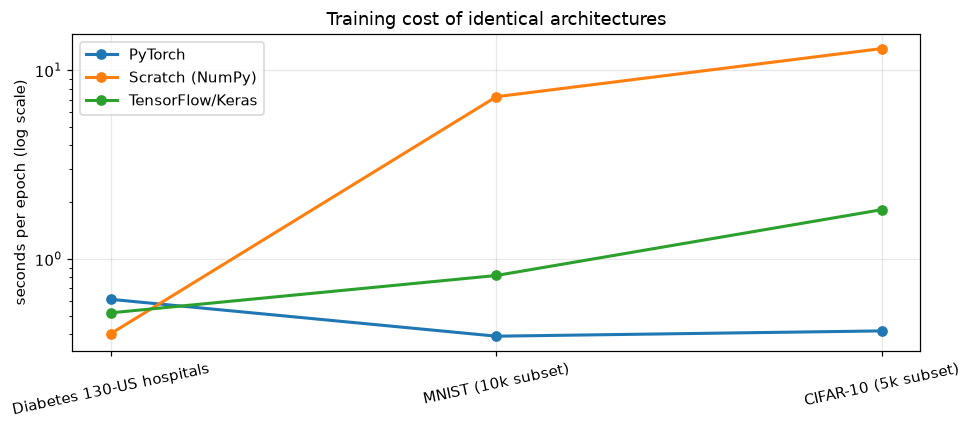

Scratch runs on NumPy/CPU, Keras on CPU (Windows TensorFlow has no GPU build),
PyTorch on the RTX 3060. The gap measures implementation and hardware, not mathematics.


In [6]:
# Training cost. Note the log scale: this is the one column where the three legs differ enormously.
fig, ax = plt.subplots(figsize=(9, 4))
for fw, grp in sub.groupby("framework"):
    ax.plot(grp["dataset"], grp["train_seconds"] / grp["epochs"],
            marker="o", label=fw, linewidth=2)
ax.set_yscale("log")
ax.set_ylabel("seconds per epoch (log scale)")
ax.set_title("Training cost of identical architectures")
ax.tick_params(axis="x", rotation=12)
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
plt.show()

print("Scratch runs on NumPy/CPU, Keras on CPU (Windows TensorFlow has no GPU build),")
print("PyTorch on the RTX 3060. The gap measures implementation and hardware, not mathematics.")

## 1.2 Số tham số khớp với phép tính tay

Mỗi notebook đều tự đếm số tham số bằng tay theo công thức §43 của tài liệu trước khi dựng bất cứ thứ gì, rồi
mới đối chiếu cả ba framework với con số đó.

In [7]:
param_check = (all_runs.groupby(["dataset", "model"])["n_params"]
               .agg(["nunique", "first"])
               .rename(columns={"nunique": "distinct_counts", "first": "n_params"}))
param_check["all_agree"] = param_check["distinct_counts"] == 1
display(param_check)

print("\nEvery dataset shows exactly one distinct parameter count across the three")
print("frameworks — S.Dense, keras.layers.Dense and nn.Linear build the same function.")

,,distinct_counts,n_params,all_agree
dataset,model,,,
CIFAR-10 (5k subset),SmallCNN,1,545098,True
CIFAR-10 (full 50k),SmallCNN,1,545098,True
Diabetes 130-US hospitals,MLP 179-128-64-3,1,31491,True
MNIST (10k subset),CNN 2conv+fc,1,20490,True
MNIST (full 60k),CNN 2conv+fc,1,20490,True



Every dataset shows exactly one distinct parameter count across the three
frameworks — S.Dense, keras.layers.Dense and nn.Linear build the same function.


## 1.3 Bảng thành phần (slide 28 của bài giảng)

Slide 28 yêu cầu sinh viên nộp bảng này. Đây là bản gộp từ cả ba notebook.

In [8]:
comp = pd.DataFrame(payloads["results/03_cifar10.json"]["component_table"])
display(comp)

,Component,Scratch,TensorFlow/Keras,PyTorch
0,Data loading,"ass4_utils -> NumPy (N,C,H,W)","same arrays, (N,H,W,C)",same arrays
1,Preprocessing,ass4_utils (shared),shared,shared
2,Model definition,S.Sequential([...]),keras.Sequential([...]),nn.Module
3,Convolution,S.Conv2D (im2col + matmul),keras.layers.Conv2D,nn.Conv2d
4,Activation,S.ReLU,activation='relu',nn.ReLU
5,Pooling,S.MaxPool2D,keras.layers.MaxPooling2D,nn.MaxPool2d
6,Flatten,S.Flatten,keras.layers.Flatten,nn.Flatten
7,Dense layer,S.Dense,keras.layers.Dense,nn.Linear
8,Loss,S.SoftmaxCrossEntropy,SparseCategoricalCrossentropy,nn.CrossEntropyLoss
9,Gradient,hand-derived backward + col2im,automatic (GradientTape),automatic (autograd)


## 1.4 Ánh xạ chức năng sang API (slide 18 của bài giảng)

Cùng một vai trò tính toán, dưới ba cái tên.

In [9]:
mapping = pd.DataFrame([
    ["Convolution",  "conv2d() via im2col",       "Conv2D",             "nn.Conv2d"],
    ["Activation",   "relu() mask multiply",      "ReLU",               "nn.ReLU"],
    ["Pooling",      "max_pool2d() argmax route", "MaxPooling2D",       "nn.MaxPool2d"],
    ["Flatten",      "flatten() reshape",         "Flatten",            "nn.Flatten"],
    ["Dense",        "linear() x@W+b",            "Dense",              "nn.Linear"],
    ["Loss",         "manual softmax + CE",       "Keras loss",         "PyTorch loss"],
    ["Gradient",     "manual (hand-derived)",     "autodiff",           "autograd"],
    ["Optimizer",    "manual Adam arithmetic",    "Keras optimizer",    "PyTorch optimizer"],
], columns=["Function", "Scratch", "Keras", "PyTorch"])
display(mapping)

visibility = pd.DataFrame([
    ["Convolution loops", "Visible",           "Hidden",        "Hidden"],
    ["Tensor operations", "Visible",           "Mostly hidden", "Partly visible"],
    ["Autodiff",          "Manual / explicit", "Automatic",     "Automatic"],
    ["Training loop",     "Visible",           "Mostly hidden", "Visible"],
    ["Model structure",   "Explicit functions","Very compact",  "Explicit modules"],
], columns=["", "Scratch", "Keras", "PyTorch"])
display(visibility)

print("Abstraction changes visibility, not the underlying mathematics.")

,Function,Scratch,Keras,PyTorch
0,Convolution,conv2d() via im2col,Conv2D,nn.Conv2d
1,Activation,relu() mask multiply,ReLU,nn.ReLU
2,Pooling,max_pool2d() argmax route,MaxPooling2D,nn.MaxPool2d
3,Flatten,flatten() reshape,Flatten,nn.Flatten
4,Dense,linear() x@W+b,Dense,nn.Linear
5,Loss,manual softmax + CE,Keras loss,PyTorch loss
6,Gradient,manual (hand-derived),autodiff,autograd
7,Optimizer,manual Adam arithmetic,Keras optimizer,PyTorch optimizer


,,Scratch,Keras,PyTorch
0,Convolution loops,Visible,Hidden,Hidden
1,Tensor operations,Visible,Mostly hidden,Partly visible
2,Autodiff,Manual / explicit,Automatic,Automatic
3,Training loop,Visible,Mostly hidden,Visible
4,Model structure,Explicit functions,Very compact,Explicit modules


Abstraction changes visibility, not the underlying mathematics.


## 1.5 Tám câu hỏi (slide 24 của bài giảng)

Slide 24 liệt kê những gì sinh viên phải trả lời được sau khi cài đặt cả ba phiên bản. Trả lời ở đây cho mô
hình `SmallCNN` trên CIFAR-10.

| # | Câu hỏi | Trả lời |
|---|----------|--------|
| 1 | Đầu vào được biểu diễn thế nào? | `B × 3 × 32 × 32` — một lô ảnh ba kênh, chuẩn hoá theo từng kênh bằng thống kê của tập huấn luyện. Keras nhận đúng tensor đó ở dạng chuyển vị `B × 32 × 32 × 3`. |
| 2 | Mỗi tầng tính cái gì? | `Conv2d(3→32,k3,p1)`: 32 tổng có trọng số cục bộ trên từng lân cận 3×3×3. `ReLU`: `max(0,x)`. `MaxPool(2)`: giá trị lớn nhất trong mỗi cửa sổ 2×2. `Flatten`: đổi hình dạng về vector. `Linear`: `xW + b`. |
| 3 | Kích thước sau mỗi tầng là bao nhiêu? | `3×32×32 → 32×32×32 → 32×16×16 → 64×16×16 → 64×8×8 → 4096 → 128 → 10`. Đệm 1 với hạt nhân 3×3 giữ nguyên kích thước; chỉ có gộp mới thu nhỏ. |
| 4 | Tham số nào học được? | Mọi hạt nhân tích chập và độ lệch (bias), mọi ma trận trọng số và độ lệch của tầng dày đặc — tổng cộng 545.098. Gộp, ReLU và flatten không giữ tham số nào. |
| 5 | Lượt lan truyền xuôi nằm ở đâu? | Scratch: `Sequential.forward`, gọi lần lượt từng tầng. Keras: ngầm trong `Sequential`. PyTorch: phương thức `forward()`. |
| 6 | Hàm mất mát tính ở đâu? | Scratch: `SoftmaxCrossEntropy.forward`. Keras: bên trong `fit()`, cấu hình bằng `compile()`. PyTorch: `criterion(logits, labels)`. |
| 7 | Gradient tính ở đâu? | Scratch: `backward()` tự dẫn bằng tay ở từng tầng, với `col2im` cộng dồn các cửa sổ chồng lấn. Keras: autodiff bên trong `fit()`. PyTorch: `loss.backward()` qua autograd. |
| 8 | Tham số được cập nhật ở đâu? | Scratch: `Adam.step()`, viết ra thành phép tính. Keras: bộ tối ưu bên trong `fit()`. PyTorch: `optimizer.step()`. |

---
# Phần 2 — Cải tiến mô hình CNN (§45 của tài liệu)

## 2.1 Bốn mô hình

Cả bốn dùng chung một bộ khung — ba giai đoạn `Conv → [chuẩn hoá] → ReLU → gộp`, nở dần 3 → 32 → 64 → 128, rồi
tới phần đầu phân loại. Chúng chỉ khác nhau ở chỗ bật cơ chế nào.

### Phần đầu phân loại: gộp trung bình toàn cục, không phải flatten

Notebook 3 kết thúc bằng một chẩn đoán: 96 % tham số của `SmallCNN` nằm ở bước `Flatten → Linear(4096→128)`,
trong khi các tầng tích chập thực sự trích xuất đặc trưng giữ chưa tới 20.000. Các mô hình ở đây dùng phần đầu
của chính mô hình `EducationalCNN` (§41) trong tài liệu:

$$\text{AdaptiveAvgPool}(1) \rightarrow \text{Flatten} \rightarrow \text{Linear}(128 \rightarrow 10)$$

Lấy trung bình mỗi bản đồ trong 128 bản đồ đặc trưng về một con số khiến bộ phân loại chỉ nhận 128 đầu vào thay
vì 4096, và đó là lý do các mô hình này **nhỏ hơn** mô hình nền ở notebook 3 dù sâu hơn.

### Mỗi cơ chế xử lý hạn chế gì

| Mô hình | Thêm vào | Hạn chế mà nó xử lý |
|---|---|---|
| $M_1$ | — | mô hình nền: `Conv + ReLU + Pool` |
| $M_2$ | **BatchNorm** | kích hoạt trôi dần giữa các tầng và giữa các lô, làm việc tối ưu chậm lại và kém ổn định |
| $M_3$ | **Residual** `Y = F(X) + X` | tăng độ sâu không còn giúp ích — gradient và thông tin không có đường đi thẳng qua cả chồng tầng |
| $M_4$ | **Chú ý SE** | mọi kênh bị đối xử như nhau, dù có kênh mang nhiều tín hiệu hơn hẳn |

Khối squeeze-and-excitation chính là cơ chế chú ý theo kênh ở §31 của tài liệu: ép mỗi bản đồ đặc trưng về một
số bằng gộp trung bình toàn cục, học từ đó một cổng $s \in \mathbb{R}^C$, rồi nhân lại — $Y_c = s_c X_c$. Nó
trả lời câu hỏi **kênh nào quan trọng**.

In [10]:
import inspect

# The models live in variants.py so that this notebook and prefill_variants.py
# build provably identical networks. Shown here rather than hidden behind an import.
print(inspect.getsource(V.SEBlock))
print(inspect.getsource(V.Stage))
print(inspect.getsource(V.VariantCNN))

class SEBlock(nn.Module):
    """Tutorial section 31: squeeze -> excite -> rescale. Answers "which channels matter?"."""

    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        s = self.pool(x).view(b, c)
        s = self.fc(s).view(b, c, 1, 1)
        return x * s

class Stage(nn.Module):
    """Two 3x3 convolutions, then halve the spatial size."""

    def __init__(self, in_ch, out_ch, use_bn=False, use_residual=False, use_se=False):
        super().__init__()
        self.use_residual = use_residual

        def norm(c):
            return nn.BatchNorm2d(c) if use_bn else nn.Identity()

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, paddin

In [11]:
print(f"{'model':<22}{'params':>10}   mechanisms")
print("-" * 62)
for name, cfg in V.VARIANTS.items():
    m = V.build(name)
    on = ", ".join(k.replace("use_", "") for k, v in cfg.items() if v) or "none"
    print(f"{name:<22}{sum(p.numel() for p in m.parameters()):>10,}   {on}")

print(f"\nstage widths: 3 -> {' -> '.join(map(str, V.WIDTHS))}")
print(f"epochs: {V.EPOCHS}, batch size: {V.BATCH_SIZE}, optimizer: Adam(lr={V.LR})")

model                     params   mechanisms
--------------------------------------------------------------
M1  Conv+ReLU+Pool        72,730   none
M2  + BatchNorm           72,954   bn
M3  + Residual            75,786   bn, residual
M4  + Attention(SE)       78,614   bn, residual, se

stage widths: 3 -> 16 -> 32 -> 64
epochs: 10, batch size: 128, optimizer: Adam(lr=0.001)


## 2.2 Huấn luyện cả bốn

CIFAR-10 đầy đủ (50.000 huấn luyện / 10.000 kiểm tra), siêu tham số giống hệt nhau cho mọi mô hình — vẫn quy
tắc công bằng của Phần 1, nay áp giữa các kiến trúc thay vì giữa các framework.

### Đôi lời về cách các lần chạy này được tạo ra

Quá trình huấn luyện được **lưu điểm dừng theo từng mô hình** vào `results/variant_cache/`, và
`variants.train_variant` trả về kết quả đã lưu thay vì huấn luyện lại mô hình đã chạy xong.
`prefill_variants.py` gọi đúng hàm đó từ dòng lệnh.

Lớp trung gian ấy không phải để trang trí. GPU của máy này bị giảm xung do nhiệt rất nặng khi chạy liên tục —
nó đứng ở 96–98 °C, NVML báo SW slowdown — khiến bản thí nghiệm gốc rộng 32/64/128 và chạy 15 epoch kéo dài
khoảng ba tiếng, và bị gián đoạn hai lần trước khi xong. Bốn thay đổi làm nó khả thi:

1. **Thu hẹp các giai đoạn**, 16/32/64 thay cho 32/64/128 — còn khoảng một phần tư khối lượng tính toán.
2. **Mười epoch** thay vì mười lăm.
3. **Chia lô ngay trên GPU.** CIFAR-10 nặng khoảng 614 MB ở dạng float32 và vừa VRAM, nên tập huấn luyện được
   nạp lên một lần rồi cắt lô ngay trên thiết bị. Một `DataLoader` chạy trên `TensorDataset` phải ghép 128 lát
   tensor riêng lẻ mỗi lô bằng Python, và với mô hình nhỏ như thế này, chi phí đó lấn át hoàn toàn thời gian
   một bước: khoảng 140 giây/epoch theo cách ấy so với khoảng 83 giây khi dữ liệu nằm sẵn trên GPU.
4. **Độ chính xác hỗn hợp** (`torch.autocast` + `GradScaler`), đưa xuống khoảng 64 giây/epoch. Giảm một nửa
   khối lượng số học cũng giảm tải nhiệt, mà nhiệt mới là nút thắt thật sự ở đây.

Cộng thêm việc lưu điểm dừng theo từng mô hình, nên một lần gián đoạn chỉ tốn một mô hình chứ không tốn cả bốn.

Hai hệ quả cần nói thẳng. Các mô hình cố tình nhỏ — đó là ràng buộc phần cứng, được ghi lại chứ không giấu đi.
Và cột `train_seconds` bên dưới đo một GPU **bị giảm xung** chạy **fp16**, nên nó công bằng **giữa bốn mô hình
này** với nhau chứ không so được với thời gian ở Phần 1, vốn chạy fp32 trên GPU mát. Điều mà thí nghiệm muốn
kiểm chứng thì không bị ảnh hưởng: mỗi mô hình khác mô hình liền trước đúng một cơ chế, huấn luyện trên cùng dữ
liệu với cùng siêu tham số.

In [12]:
X_train, y_train, X_test, y_test, meta = U.load_cifar10()
CLASSES = meta["classes"]
N_CLASSES = len(CLASSES)

Xte_t = torch.tensor(X_test).to(DEVICE)

print(f"\ntrain {X_train.shape}  test {X_test.shape}")
print(f"epochs={V.EPOCHS}, batch_size={V.BATCH_SIZE}, optimizer=Adam(lr={V.LR})")
print(f"cached models: {[n.split()[0] for n in V.VARIANTS if V.cached(n)] or 'none - will train now'}")

CIFAR-10: train (50000, 3, 32, 32) / test (10000, 3, 32, 32), 10 classes

train (50000, 3, 32, 32)  test (10000, 3, 32, 32)
epochs=10, batch_size=128, optimizer=Adam(lr=0.001)
cached models: ['M1', 'M2', 'M3', 'M4']


In [13]:
variant_results, variant_models = [], {}

for name in V.VARIANTS:
    record = V.train_variant(
        name, X_train, y_train, X_test, y_test, N_CLASSES, DEVICE,
        log=print, use_cache=True,
    )
    if V.cached(name) is not None:
        V.replay(record)          # show the per-epoch history behind a cached result

    variant_results.append(U.RunResult(**record))

    m = V.load_model(name, X_train.shape[1], N_CLASSES, DEVICE)
    if m is not None:
        variant_models[name] = m

print(f"{len(variant_results)} variants ready")

M1  Conv+ReLU+Pool: loaded from cache (72,730 params, 10 epochs, 552s on the original run)
=== M1  Conv+ReLU+Pool  (72,730 parameters) ===
  epoch  1/10  loss 1.8106  test_acc 0.3973
  epoch  2/10  loss 1.4745  test_acc 0.4867
  epoch  3/10  loss 1.3244  test_acc 0.5474
  epoch  4/10  loss 1.1853  test_acc 0.5733
  epoch  5/10  loss 1.0895  test_acc 0.5988
  epoch  6/10  loss 1.0166  test_acc 0.6478
  epoch  7/10  loss 0.9576  test_acc 0.6641
  epoch  8/10  loss 0.9122  test_acc 0.6697
  epoch  9/10  loss 0.8737  test_acc 0.6749
  epoch 10/10  loss 0.8397  test_acc 0.6947
  final: accuracy 0.6947  macro-F1 0.6956  (552s)
M2  + BatchNorm: loaded from cache (72,954 params, 10 epochs, 573s on the original run)
=== M2  + BatchNorm  (72,954 parameters) ===
  epoch  1/10  loss 1.3191  test_acc 0.5394
  epoch  2/10  loss 0.9332  test_acc 0.6499
  epoch  3/10  loss 0.7922  test_acc 0.6696
  epoch  4/10  loss 0.7009  test_acc 0.7083
  epoch  5/10  loss 0.6334  test_acc 0.7553
  epoch  6/10  los

## 2.3 Kết quả

§45 nói rõ rằng chỉ đọc độ chính xác là đọc sai. Phép so sánh phải là **độ chính xác + số tham số + thời gian
huấn luyện + hành vi biểu diễn**.

In [14]:
vtable = U.results_table(variant_results)
display(vtable)

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,PyTorch,CIFAR-10 (full 50k),M1 Conv+ReLU+Pool,72730,10,552.30,0.8397,0.6947,0.7144,0.6947,0.6956
1,PyTorch,CIFAR-10 (full 50k),M2 + BatchNorm,72954,10,573.48,0.4489,0.7524,0.7836,0.7524,0.7573
2,PyTorch,CIFAR-10 (full 50k),M3 + Residual,75786,10,681.64,0.4485,0.7639,0.7917,0.7639,0.7696
3,PyTorch,CIFAR-10 (full 50k),M4 + Attention(SE),78614,10,766.25,0.4402,0.7367,0.7841,0.7367,0.7468


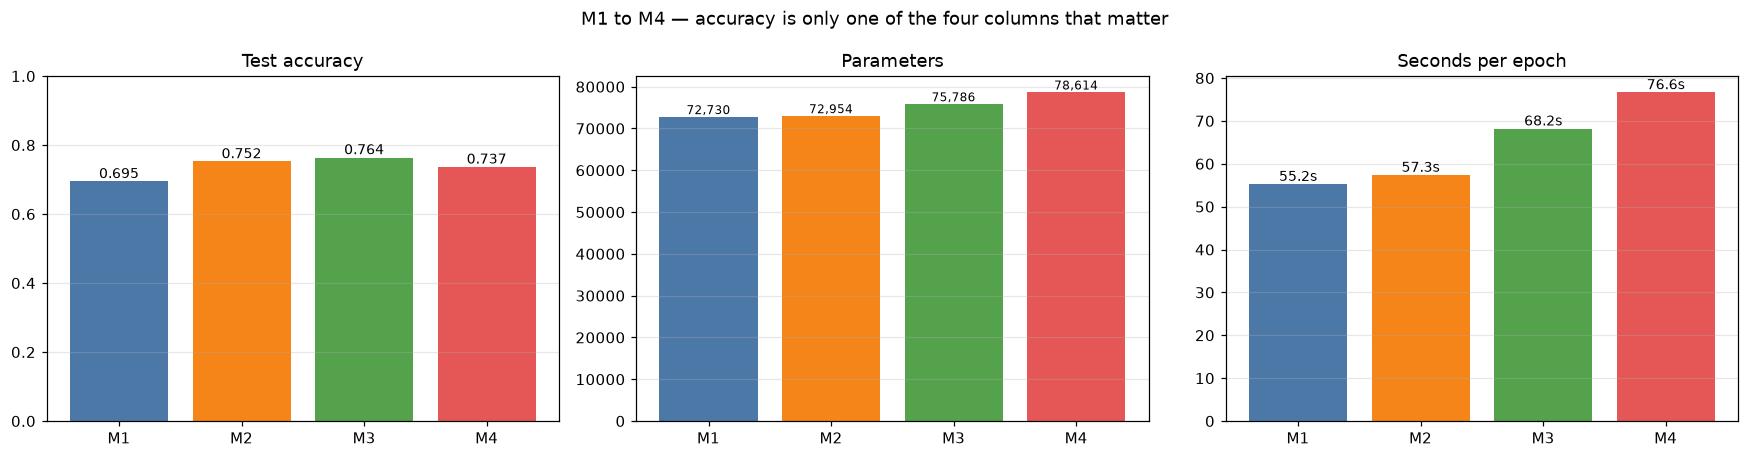

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
names = [r.model for r in variant_results]
short = [n.split()[0] for n in names]
colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

accs = [r.test_accuracy for r in variant_results]
bars = ax[0].bar(short, accs, color=colors)
ax[0].set_title("Test accuracy"); ax[0].set_ylim(0, 1); ax[0].grid(alpha=0.3, axis="y")
for b, v in zip(bars, accs):
    ax[0].text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

prm = [r.n_params for r in variant_results]
bars = ax[1].bar(short, prm, color=colors)
ax[1].set_title("Parameters"); ax[1].grid(alpha=0.3, axis="y")
for b, v in zip(bars, prm):
    ax[1].text(b.get_x() + b.get_width() / 2, v, f"{v:,}", ha="center", va="bottom", fontsize=8)

tm = [r.train_seconds / r.epochs for r in variant_results]
bars = ax[2].bar(short, tm, color=colors)
ax[2].set_title("Seconds per epoch"); ax[2].grid(alpha=0.3, axis="y")
for b, v in zip(bars, tm):
    ax[2].text(b.get_x() + b.get_width() / 2, v, f"{v:.1f}s", ha="center", va="bottom", fontsize=9)

fig.suptitle("M1 to M4 — accuracy is only one of the four columns that matter")
fig.tight_layout()
plt.show()

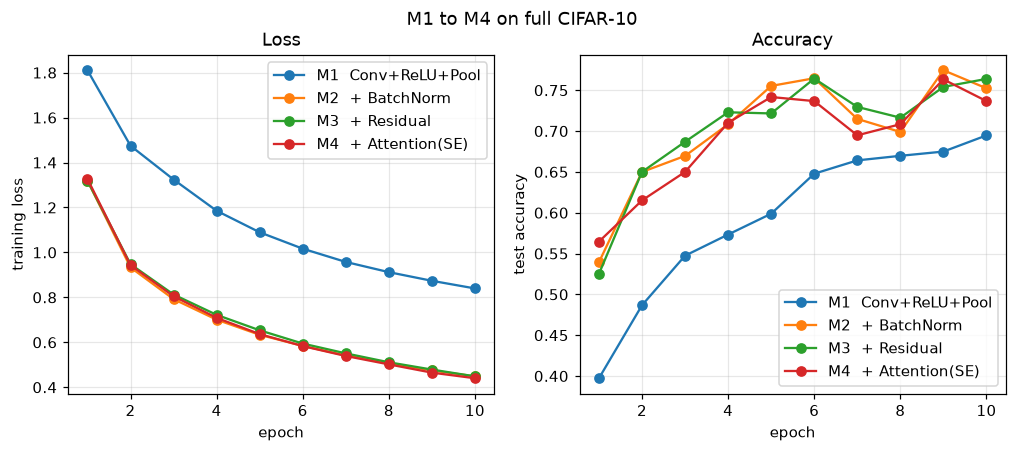

In [16]:
U.plot_history({r.model: r.history for r in variant_results},
               title="M1 to M4 on full CIFAR-10")
plt.show()

In [17]:
# Accuracy per unit of cost - what each mechanism actually bought.
base = variant_results[0]
rows = []
for r in variant_results:
    rows.append({
        "model": r.model,
        "accuracy": r.test_accuracy,
        "delta_vs_M1": r.test_accuracy - base.test_accuracy,
        "params": r.n_params,
        "extra_params_vs_M1": r.n_params - base.n_params,
        "sec_per_epoch": round(r.train_seconds / r.epochs, 2),
        "slowdown_vs_M1": round((r.train_seconds / base.train_seconds), 2),
    })
display(pd.DataFrame(rows).round(4))

,model,accuracy,delta_vs_M1,params,extra_params_vs_M1,sec_per_epoch,slowdown_vs_M1
0,M1 Conv+ReLU+Pool,0.6947,0.0000,72730,0,55.23,1.00
1,M2 + BatchNorm,0.7524,0.0577,72954,224,57.35,1.04
2,M3 + Residual,0.7639,0.0692,75786,3056,68.16,1.23
3,M4 + Attention(SE),0.7367,0.0420,78614,5884,76.62,1.39


### Hành vi biểu diễn

Ngoài con số tổng: mỗi mô hình làm đúng ở những lớp nào. Một cơ chế nâng độ chính xác tổng thể bằng cách cứu
các lớp khó nhất đang làm một việc khác hẳn so với cơ chế chỉ làm sắc nét thêm những lớp vốn đã dễ.

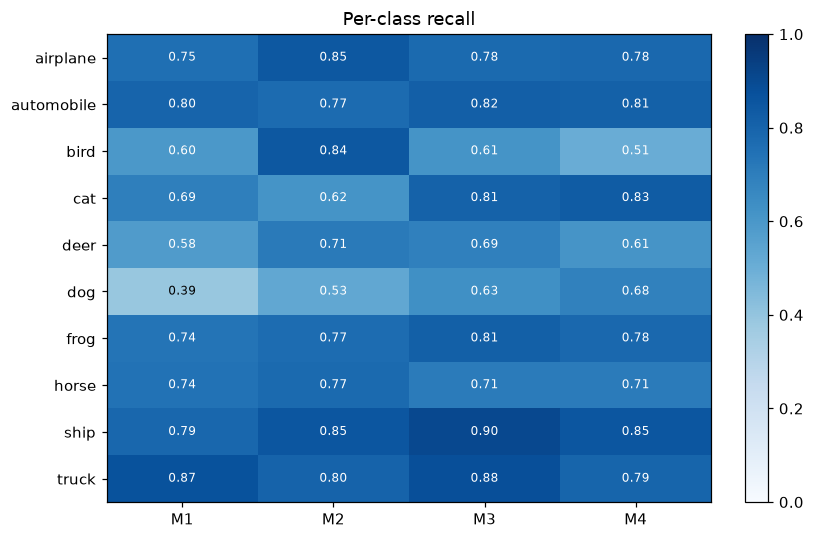

hardest class for M1: dog  (0.390 recall)
  M4 on the same class: 0.684

std-dev of per-class recall (lower = more even across classes):
  M1: 0.1387
  M2: 0.1055
  M3: 0.0995
  M4: 0.1092


In [18]:
per_class = pd.DataFrame(
    {r.model.split()[0]: np.diag(np.array(r.confusion)) / np.array(r.confusion).sum(axis=1)
     for r in variant_results},
    index=CLASSES,
)

fig, ax = plt.subplots(figsize=(7.5, 5))
im = ax.imshow(per_class.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(per_class.shape[1]), per_class.columns)
ax.set_yticks(range(len(CLASSES)), CLASSES)
ax.set_title("Per-class recall")
for i in range(per_class.shape[0]):
    for j in range(per_class.shape[1]):
        v = per_class.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if v > 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

worst = per_class.index[per_class["M1"].argmin()]
print(f"hardest class for M1: {worst}  ({per_class.loc[worst, 'M1']:.3f} recall)")
print(f"  M4 on the same class: {per_class.loc[worst, 'M4']:.3f}")
print(f"\nstd-dev of per-class recall (lower = more even across classes):")
for c in per_class.columns:
    print(f"  {c}: {per_class[c].std():.4f}")

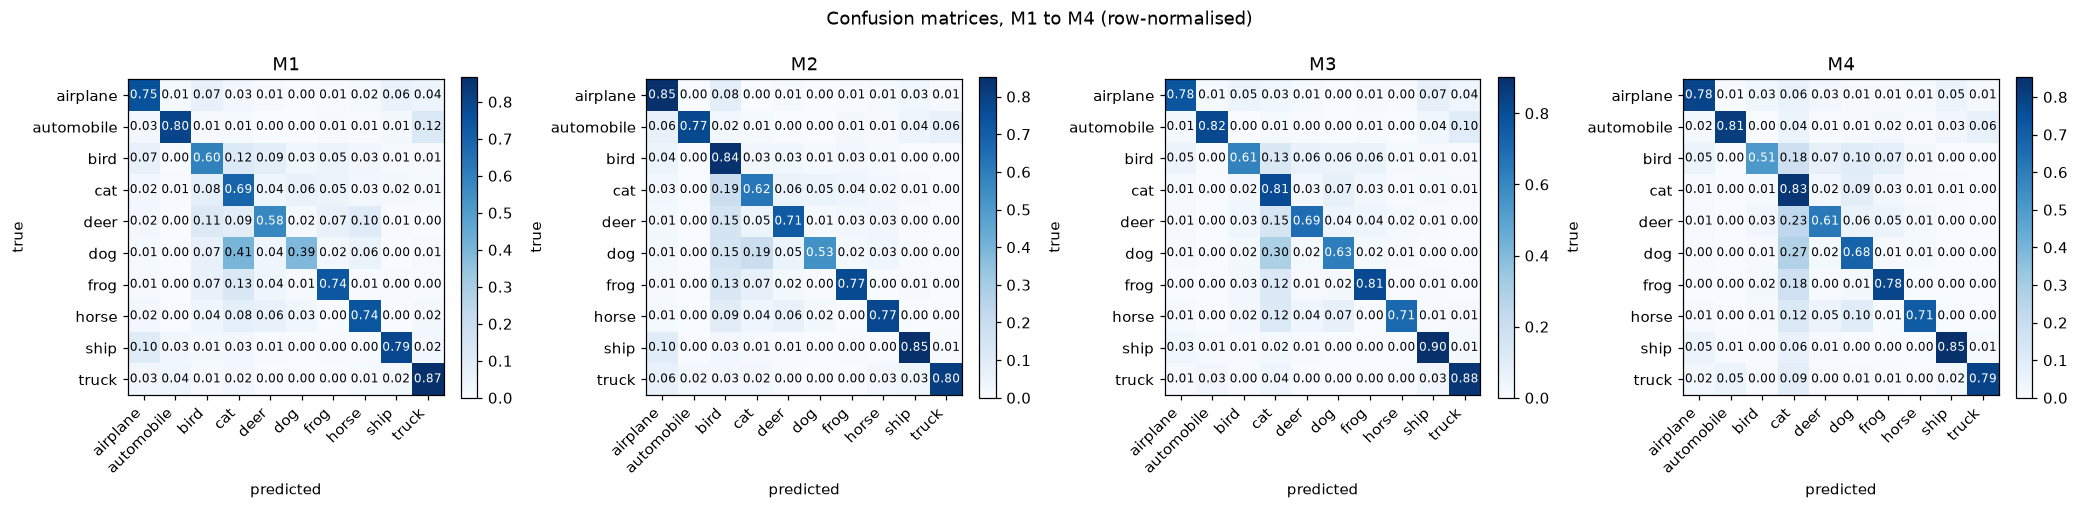

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.6))
for ax_, r in zip(axes, variant_results):
    U.plot_confusion(r.confusion, CLASSES, title=r.model.split()[0], ax=ax_)
fig.suptitle("Confusion matrices, M1 to M4 (row-normalised)")
fig.tight_layout()
plt.show()

### Cổng SE đã học được gì

Khối chú ý của $M_4$ sinh ra một trọng số cho mỗi kênh, trên mỗi ảnh. Nếu các trọng số ấy bằng nhau hết thì
khối đó chẳng làm gì cả; phân phối có độ tản nghĩa là mô hình thật sự coi một số kênh quan trọng hơn, và coi
khác nhau với các đầu vào khác nhau.

Chỗ này đáng kiểm tra **chính vì** $M_4$ đạt điểm thấp hơn $M_3$. Một cơ chế thêm vào có thể hỏng theo hai kiểu
khác nhau: nó nằm im, chỉ góp thêm tham số chứ không góp gì khác; hoặc nó hoạt động thật mà vẫn không giúp
được. Phân phối cổng bên dưới phân biệt hai kiểu đó — và câu trả lời làm đổi ý nghĩa của bước tụt điểm.

SE gate values from the last stage: shape (512, 64) (images x channels)
range 0.001 to 1.000, mean 0.986


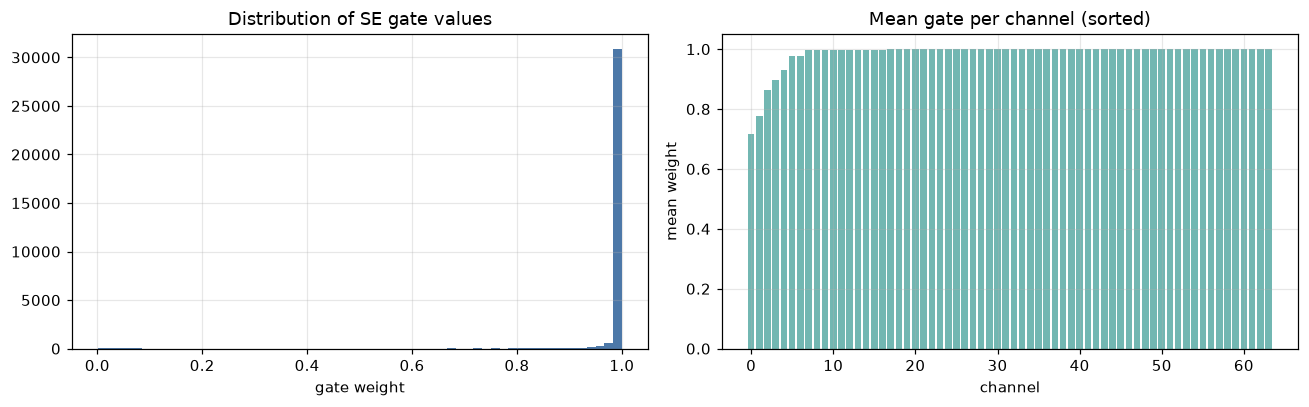


If attention were inert every value would sit at one point. The spread (0.092 std-dev) is the model down-weighting some channels and amplifying others, per image.


In [20]:
m4 = variant_models["M4  + Attention(SE)"]
m4.eval()

gates = []
hook_target = m4.stages[2].se
with torch.no_grad():
    def grab(module, inp, out):
        b, c, _, _ = inp[0].shape
        s = module.pool(inp[0]).view(b, c)
        gates.append(module.fc(s).cpu().numpy())

    h = hook_target.register_forward_hook(grab)
    m4(Xte_t[:512])
    h.remove()

g = np.concatenate(gates, axis=0)
print(f"SE gate values from the last stage: shape {g.shape} (images x channels)")
print(f"range {g.min():.3f} to {g.max():.3f}, mean {g.mean():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].hist(g.ravel(), bins=60, color="#4C78A8")
ax[0].set_title("Distribution of SE gate values")
ax[0].set_xlabel("gate weight"); ax[0].grid(alpha=0.3)

order = np.argsort(g.mean(axis=0))
ax[1].bar(range(g.shape[1]), g.mean(axis=0)[order], color="#72B7B2")
ax[1].set_title("Mean gate per channel (sorted)")
ax[1].set_xlabel("channel"); ax[1].set_ylabel("mean weight"); ax[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"\nIf attention were inert every value would sit at one point. The spread "
      f"({g.std():.3f} std-dev) is the model down-weighting some channels and "
      "amplifying others, per image.")

## 2.4 Vấn đề và giải pháp

§39 của tài liệu trình bày sự tiến hoá kiến trúc dưới dạng một bảng vấn đề — giải pháp. Dưới đây là bảng ấy,
điền theo đúng những gì đã đo được ở trên.

In [21]:
evolution = pd.DataFrame([
    ["Only linear transformations", "Activation (ReLU)",   "Nonlinearity",                 "all models"],
    ["Too many image parameters",   "Convolution",         "Locality + weight sharing",    "all models"],
    ["Large spatial size",          "Pooling / stride",    "Downsampling",                 "all models"],
    ["Flatten blows up the head",   "Global average pool", "128 inputs instead of 4096",   "all models"],
    ["Activations drift",           "BatchNorm",           "Stable, faster optimisation",  "M2 onward"],
    ["Depth stops helping",         "Residual Y=F(X)+X",   "Direct gradient/info path",    "M3 onward"],
    ["Channels unequally useful",   "SE channel attention","Selective weighting",          "M4"],
], columns=["Problem", "Operation", "Purpose", "Present in"])
display(evolution)

,Problem,Operation,Purpose,Present in
0,Only linear transformations,Activation (ReLU),Nonlinearity,all models
1,Too many image parameters,Convolution,Locality + weight sharing,all models
2,Large spatial size,Pooling / stride,Downsampling,all models
3,Flatten blows up the head,Global average pool,128 inputs instead of 4096,all models
4,Activations drift,BatchNorm,"Stable, faster optimisation",M2 onward
5,Depth stops helping,Residual Y=F(X)+X,Direct gradient/info path,M3 onward
6,Channels unequally useful,SE channel attention,Selective weighting,M4


In [22]:
os.makedirs("results", exist_ok=True)
with open("results/04_variants.json", "w") as f:
    json.dump({"variants": [r.__dict__ for r in variant_results],
               "per_class_recall": per_class.to_dict()},
              f, indent=2, default=str)

all_runs_final = pd.concat([all_runs, U.results_table(variant_results)], ignore_index=True)
all_runs_final.to_csv("results/all_runs.csv", index=False)
print("saved results/04_variants.json and results/all_runs.csv")
display(all_runs_final.round(4))

saved results/04_variants.json and results/all_runs.csv


,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),Diabetes 130-US hospitals,MLP 179-128-64-3,31491,15,6.04,0.8237,0.6094,0.4798,0.3728,0.3450
1,TensorFlow/Keras,Diabetes 130-US hospitals,MLP 179-128-64-3,31491,15,7.78,0.8174,0.6077,0.4839,0.3842,0.3686
2,PyTorch,Diabetes 130-US hospitals,MLP 179-128-64-3,31491,15,9.17,0.8135,0.6105,0.5129,0.3860,0.3694
3,Scratch (NumPy),MNIST (10k subset),CNN 2conv+fc,20490,5,36.24,0.0525,0.9810,0.9813,0.9810,0.9810
4,TensorFlow/Keras,MNIST (10k subset),CNN 2conv+fc,20490,5,4.09,0.0665,0.9755,0.9765,0.9754,0.9756
5,PyTorch,MNIST (10k subset),CNN 2conv+fc,20490,5,1.95,0.0569,0.9835,0.9838,0.9835,0.9836
6,PyTorch,MNIST (full 60k),CNN 2conv+fc,20490,5,9.06,0.0299,0.9875,0.9875,0.9875,0.9874
7,TensorFlow/Keras,MNIST (full 60k),CNN 2conv+fc,20490,5,19.19,0.0275,0.9855,0.9855,0.9854,0.9854
8,Scratch (NumPy),CIFAR-10 (5k subset),SmallCNN,545098,5,65.23,1.0515,0.5055,0.5216,0.5080,0.5032
9,TensorFlow/Keras,CIFAR-10 (5k subset),SmallCNN,545098,5,9.13,0.7654,0.5485,0.5687,0.5485,0.5452


---
# Kết luận

## Về ba cách cài đặt

**Framework không làm đổi mô hình.** Qua ba bộ dữ liệu và hai họ mô hình, ba nhánh NumPy thuần, TensorFlow/Keras
và PyTorch cho ra **số tham số giống hệt nhau** và **kích thước tensor giống hệt nhau ở mọi giai đoạn** — khớp
tuyệt đối chứ không phải xấp xỉ, và đó là bằng chứng mạnh nhất ở đây. Tên gọi khác nhau — `S.Dense`,
`keras.layers.Dense`, `nn.Linear` — không kéo theo khái niệm học máy khác nhau.

Độ chính xác chênh nhau vài điểm trên các tập con nhỏ. Mục 1.1 đo thẳng sàn nhiễu bằng cách chạy lại một mô
hình với năm hạt ngẫu nhiên, và phép so sánh ở đó là cách đọc trung thực cho những khoảng chênh ấy: thứ khác
nhau giữa các framework là cách khởi tạo trọng số và thứ tự xáo dữ liệu, không phải hàm số được tính. Năm hạt
là mẫu nhỏ, nên kết luận được phát biểu ở mức độ mạnh của bằng chứng, không phải ở mức chứng minh.

**Thứ thay đổi là mức độ nhìn thấy.** Bản scratch phơi bày mọi đại lượng trong chu trình và phải tự dẫn gradient
— các phép kiểm tra sai phân hữu hạn ở notebook 1–3 đã xác nhận chúng đúng. Keras giấu vòng lặp, gradient và
bước cập nhật sau `fit()`. PyTorch nằm giữa: định nghĩa mô hình gọn, vòng lặp huấn luyện tường minh, autograd
nằm bên dưới. Trừu tượng hoá đánh đổi mức độ nhìn thấy lấy sự tiện lợi; phần toán thì bất biến.

**Thứ thay đổi khủng khiếp là chi phí.** Thời gian mỗi epoch chênh nhau vài bậc độ lớn giữa NumPy viết tay chạy
CPU và cuDNN chạy RTX 3060 — đó là tính chất của cách cài đặt và phần cứng, không phải của kiến trúc.

## Về việc khớp mô hình với dữ liệu

Ba bộ dữ liệu được chọn để làm rõ đúng một phân biệt. Dữ liệu bảng Diabetes không có lân cận không gian, nên
MLP là mô hình trung thực và không có phép tích chập nào xuất hiện trong notebook 1. MNIST và CIFAR-10 thì có
cấu trúc không gian, nên kết nối cục bộ và chia sẻ trọng số tự trả giá cho mình. **Mô hình phải khớp với cấu
trúc của dữ liệu** — CNN là lựa chọn được biện minh bằng một tính chất của đầu vào, không phải mặc định.

## Về các mô hình CNN cải tiến

Mỗi cơ chế xử lý một hạn chế cụ thể, và bảng so sánh bốn cột cho thấy mỗi cơ chế tốn gì chứ không chỉ mua được
gì. Đọc cả bảng thay vì chỉ đọc cột độ chính xác chính là toàn bộ ý của §45 — và lần chạy này làm bật ý đó rõ
hơn cả một kết quả đẹp đẽ.

**BatchNorm là bước thắng lớn nhất.** $M_1 \rightarrow M_2$ là bước nhảy lớn nhất trong thí nghiệm, đổi lấy 224
tham số và gần như không thêm thời gian. Chuẩn hoá kích hoạt giữa các tầng vừa rẻ vừa quan trọng.

**Kết nối tắt thêm được ít hơn.** $M_2 \rightarrow M_3$ vẫn cải thiện độ chính xác, nhưng ít hơn nhiều. Điều đó
không có gì lạ ở độ sâu này: kết nối tắt sinh ra để làm cho những chồng tầng **rất** sâu huấn luyện được, mà ba
giai đoạn thì chưa đủ sâu để vấn đề suy thoái (degradation) lộ ra. Cơ chế không phải không làm gì — nó đang
được áp vào một mạng chưa mắc cái bệnh mà nó chữa.

**Chú ý làm mọi thứ tệ đi.** $M_4$ đạt điểm **thấp hơn** $M_3$ trong khi tốn nhiều tham số nhất và nhiều thời
gian huấn luyện nhất. Điều này cần nói thẳng chứ không nên biện hộ. Ba lý do hợp lý, mà một lần chạy duy nhất
không tách bạch được:

- khối SE thêm tham số và thêm một phi tuyến nữa phải tối ưu, và mười epoch có thể đơn giản là không đủ để bù
  lại chi phí đó;
- chú ý theo kênh đáng giá khi có nhiều kênh mà mức hữu ích chênh nhau thật sự — ở mức 16/32/64 kênh thì có ít
  thứ để mà chọn lọc;
- một hạt ngẫu nhiên, không tinh chỉnh: khoảng chênh 2,7 điểm lớn hơn khác biệt giữa các framework ở Phần 1,
  nhưng thí nghiệm này không có dải nhiễu nhiều hạt của riêng nó để đối chiếu.

**Bài học trung thực đúng là bài học mà §45 yêu cầu.** "Kiến trúc mới = kiến trúc cũ + một cơ chế xử lý một hạn
chế" mô tả cách các kiến trúc **tiến hoá**; nó không hứa rằng mỗi lần thêm vào là độ chính xác tăng. Một cơ chế
giúp ích khi mô hình đang mắc đúng hạn chế mà nó nhắm tới, và bắt ta trả giá khi không. Học được điều đó từ thí
nghiệm này còn hữu ích hơn bốn cột tăng đều tăm tắp — và đó đúng là lý do §45 nói mục tiêu không chỉ là đạt độ
chính xác cao nhất.

Hình thức tổng quát vẫn đứng vững, với tư cách mô tả cách kiến trúc phát triển chứ không phải một lời bảo đảm:

$$\textbf{kiến trúc mới} = \textbf{kiến trúc cũ} + \textbf{một cơ chế xử lý một hạn chế}$$

Đó là thứ làm cho lịch sử kiến trúc học được như một chuỗi quyết định kỹ thuật thay vì một danh sách tên gọi —
và là thứ cho phép sinh viên sửa được một CNN chứ không chỉ chép lại nó.

## Giới hạn trung thực của các thí nghiệm này

- Năm epoch trên tập con cho phép so sánh ba bên, và mười epoch trên các giai đoạn thu hẹp 16/32/64 cho
  $M_1$–$M_4$, không tăng cường dữ liệu, không lịch giảm learning rate, không tinh chỉnh siêu tham số. Đây
  **không** phải những con số CIFAR-10 mang tính cạnh tranh, và cũng không nhằm như vậy.
- Thời gian của $M_1$–$M_4$ đo trên GPU bị giảm xung do nhiệt, chạy độ chính xác hỗn hợp, nên chúng so được với
  nhau nhưng không so được với thời gian fp32 ở Phần 1.
- Mỗi cấu hình chỉ một hạt ngẫu nhiên. Khác biệt giữa $M_1$ và $M_4$ lớn hơn nhiễu do hạt; khác biệt giữa ba
  **framework** thì không — và đó đúng là điều đang được khẳng định về chúng.
- TensorFlow trên Windows chỉ chạy CPU, nên thời gian thực của Keras và PyTorch đo trên hai phần cứng khác
  nhau. Số tham số và độ chính xác vẫn so trực tiếp được; thời gian huấn luyện thì không.
- Dự đoán tái nhập viện từ dữ liệu hành chính vốn khó thật. Những con số khiêm tốn ở notebook 1 phản ánh bản
  thân bài toán, không phải lỗi của cách cài đặt nào.